Ejecutar el Algoritmo Genetico sobre los datos de scRNA-seq procesados cargados desde el archivo .H5ad

In [1]:
# Establecer el autoreload

%load_ext autoreload
%autoreload 2


In [2]:
import scanpy as sc

import algoritmo_genetico as ag


In [3]:
adata = sc.read_h5ad("humanM1.h5ad")


In [4]:
# Desconvierto la matriz de expresión sparse

adata.X = adata.X.astype('float32')

In [5]:

# Definir genes disponibles

LEGO = list(range(len(adata.var)))


In [6]:
adata.obs.class_label


sample_name
AAACCCAAGGATTTCC-LKTX_190129_01_A01        GABAergic
AAACCCAAGTATGGCG-LKTX_190129_01_A01    Glutamatergic
AAACCCACAAAGTGTA-LKTX_190129_01_A01    Glutamatergic
AAACCCACACTACTTT-LKTX_190129_01_A01    Glutamatergic
AAACCCACAGTGAGCA-LKTX_190129_01_A01     Non-Neuronal
                                           ...      
TTTGTTGAGATGGCGT-LKTX_190130_01_H01     Non-Neuronal
TTTGTTGCACAGCCAC-LKTX_190130_01_H01    Glutamatergic
TTTGTTGCAGAGACTG-LKTX_190130_01_H01    Glutamatergic
TTTGTTGCATAATGAG-LKTX_190130_01_H01     Non-Neuronal
TTTGTTGTCTACTCAT-LKTX_190130_01_H01        GABAergic
Name: class_label, Length: 76533, dtype: category
Categories (3, object): ['GABAergic', 'Glutamatergic', 'Non-Neuronal']

In [11]:

# ------------------------------
# Ejecutar el Algoritmo Genético
# ------------------------------

df_historial, mejoresXgen, mejor_global,best_fitness, parametros = ag.algoritmo_genetico(
    fitness_func=ag.fitness,
    modo=0,
    LEGO=LEGO,
    IND_LEN=10,
    POP_SIZE=10,
    POP_NUM=2,
    GENS=30,
    MUT_RATE=0.1,
    MUT_NULL_RATE=0.1,
    ELITISM=0.1,
    df_expresion=adata.X,
    target = adata.obs["class_label"],
    nombres_columnas=adata.var.index, 
    modelo="rf",
    metric="f1",
    random_state=42
)




Evolución AG: 100%|████████████████████████████████████████████████████████████████| 30/30 [45:11<00:00, 90.37s/it]


NameError: name 'nombres_columnas2' is not defined

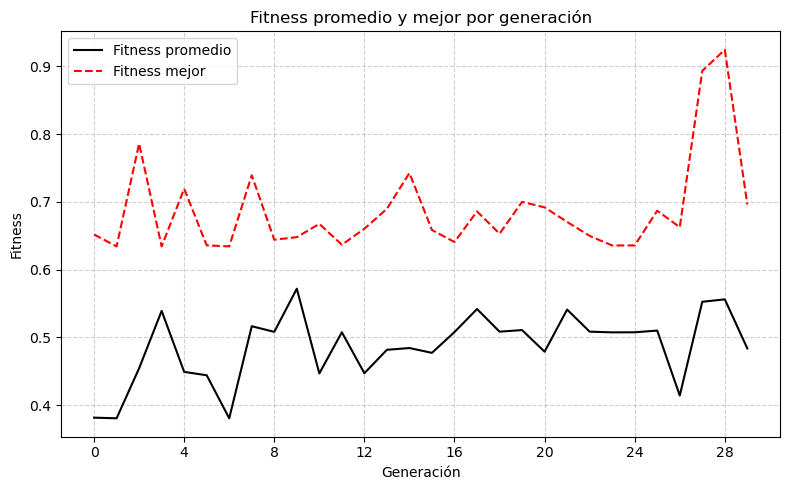

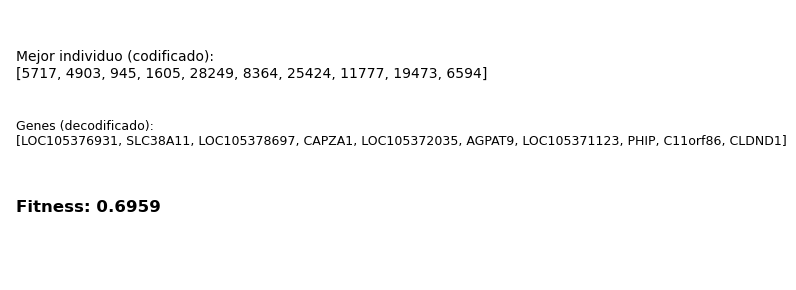

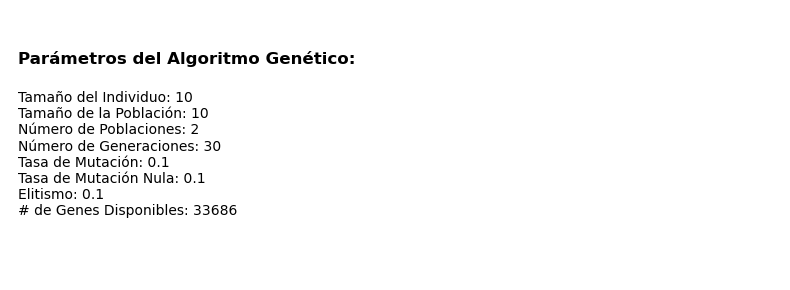

LOC105376931, SLC38A11, LOC105378697, CAPZA1, LOC105372035, AGPAT9, LOC105371123, PHIP, C11orf86, CLDND1


In [14]:
# ------------------------------
# Visualización de resultados
# ------------------------------


ag.plot_ag_results(df_historial, mejor_global,best_fitness, parametros,nombres_columnas=adata.var.index)


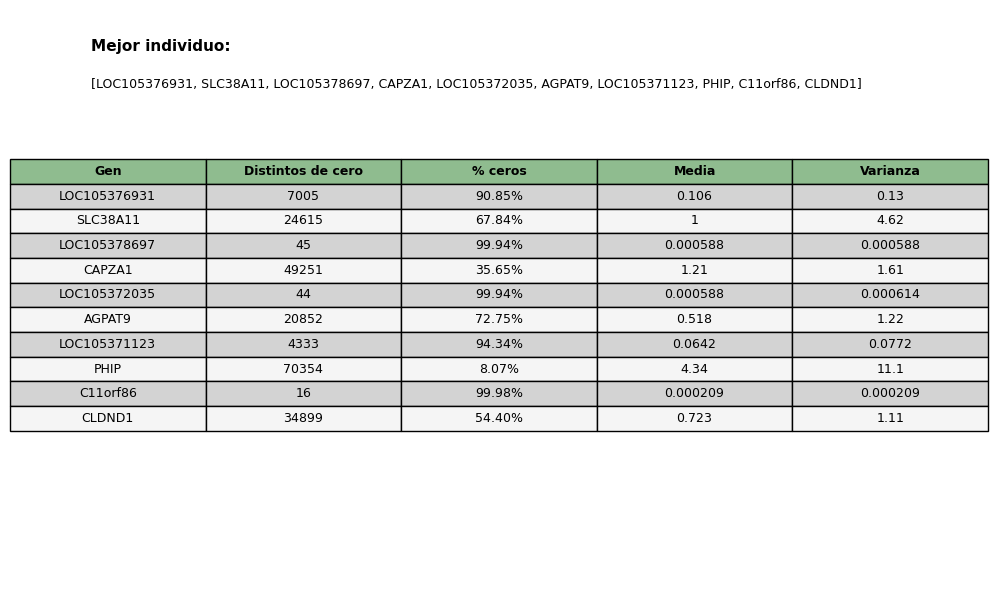

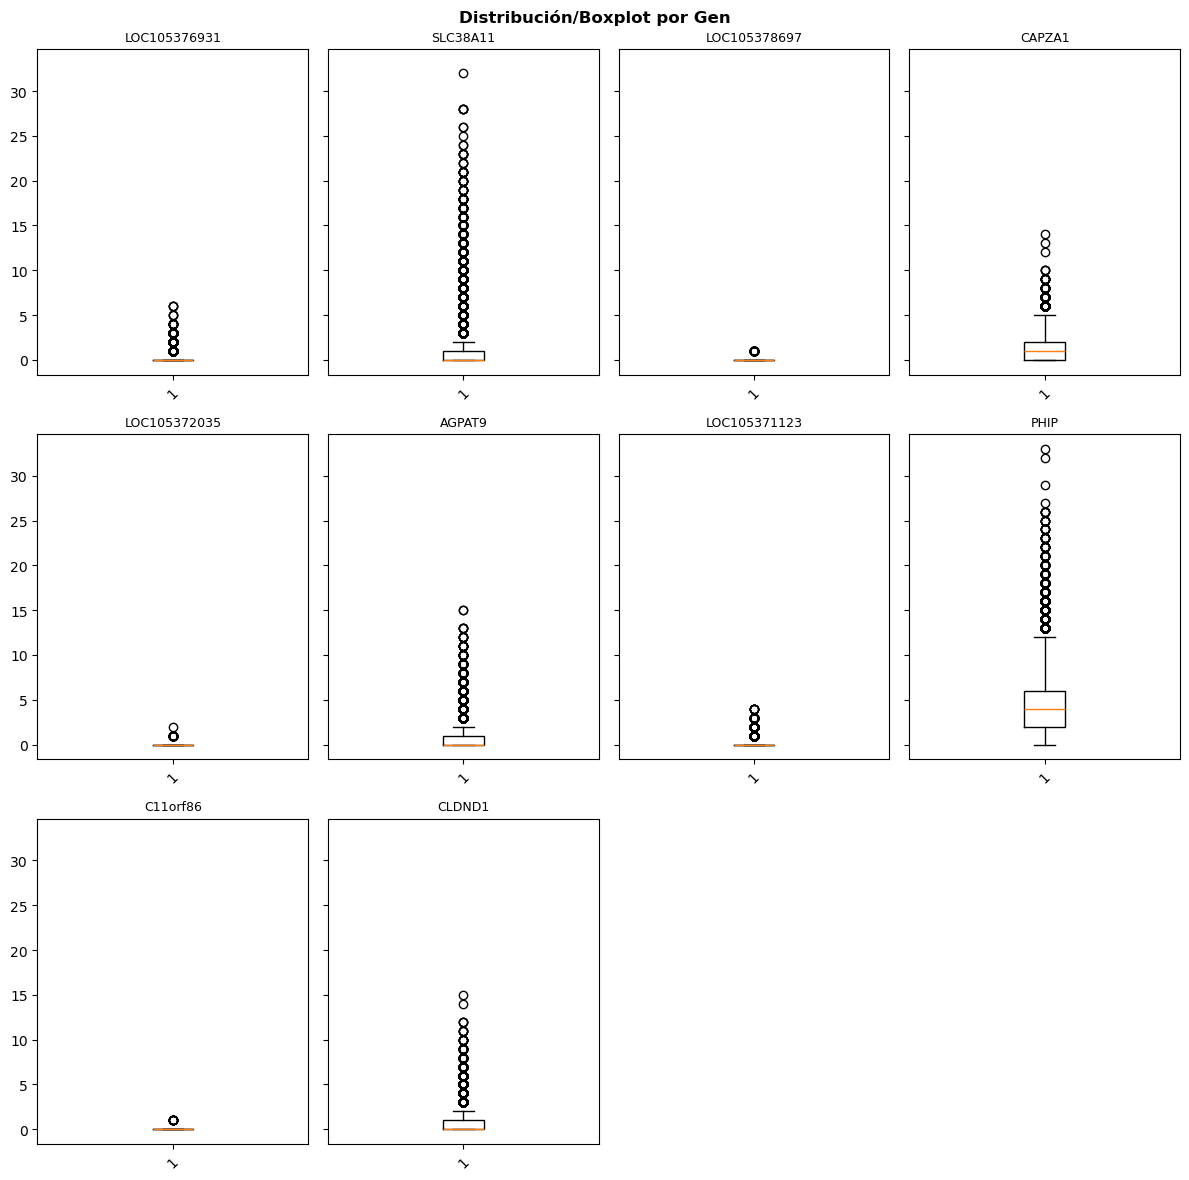

In [20]:
ag.info_individuo(mejor_global, adata.X, adata.var.index)